# Credit Card Fraud Detection — Random Forest

**Датасет:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

284 807 транзакций, из которых только **492 (0.17%) мошеннические** — сильно несбалансированный датасет.

**Сравниваем 3 стратегии балансировки:**
1. `class_weight='balanced'`
2. Random Undersampling
3. SMOTE

**Метрики:** ROC-AUC, Precision-Recall, Confusion Matrix, Calibration Curve

## 1. Установка зависимостей

In [11]:
!pip install -q imbalanced-learn

## 2. Импорты

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score, RocCurveDisplay
)
from sklearn.calibration import CalibrationDisplay
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
N_ESTIMATORS = 200
MAX_DEPTH = 12
TEST_SIZE = 0.2

print('Библиотеки загружены успешно')

Библиотеки загружены успешно


## 3. Загрузка датасета




In [13]:
df = pd.read_csv('/content/creditcard.csv')

print(f'Размер датасета: {df.shape}')
print(f'Мошеннических транзакций: {df["Class"].sum()} ({df["Class"].mean()*100:.4f}%)')
print(f'Обычных транзакций: {(df["Class"]==0).sum()}')
df.head()

Размер датасета: (284807, 31)
Мошеннических транзакций: 492 (0.1727%)
Обычных транзакций: 284315


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 4. Анализ дисбаланса классов

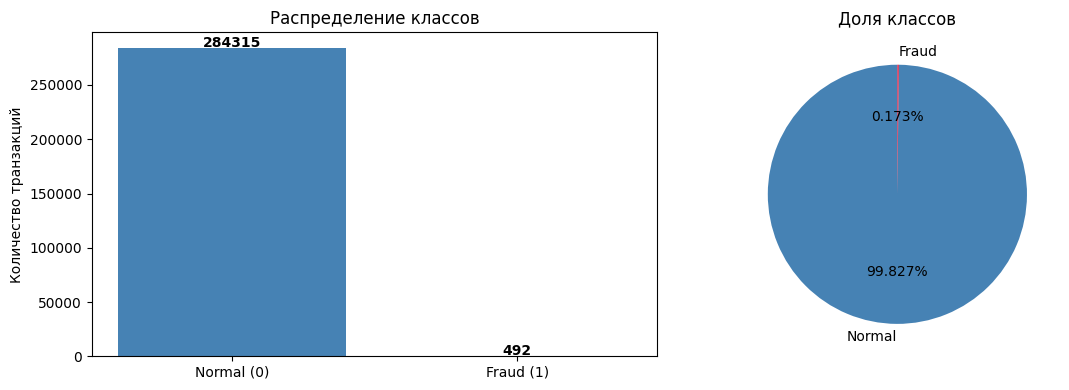

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Normal (0)', 'Fraud (1)'], counts.values, color=['steelblue', 'crimson'])
axes[0].set_title('Распределение классов')
axes[0].set_ylabel('Количество транзакций')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Normal', 'Fraud'],
            autopct='%1.3f%%', colors=['steelblue', 'crimson'],
            startangle=90)
axes[1].set_title('Доля классов')

plt.tight_layout()
plt.show()

Индекс Джинни и энтропия

Доля нормальных:     0.998273
Доля мошеннических:  0.001727

Индекс Джини:  0.003449
Энтропия:      0.018343
Если узел содержит только нормальные
Джини:    0.0000  (0 = идеально чисто)
Энтропия: 0.0000         (0 = идеально чисто)

Если узел содержит 50/50
Джини:    0.5000  (0.5 = максимальный хаос)
Энтропия: 1.0000  (1.0 = максимальный хаос)

Весь наш датасет
Джини:    0.003449  (очень чисто — 99.8% один класс)
Энтропия: 0.018343  (очень чисто)


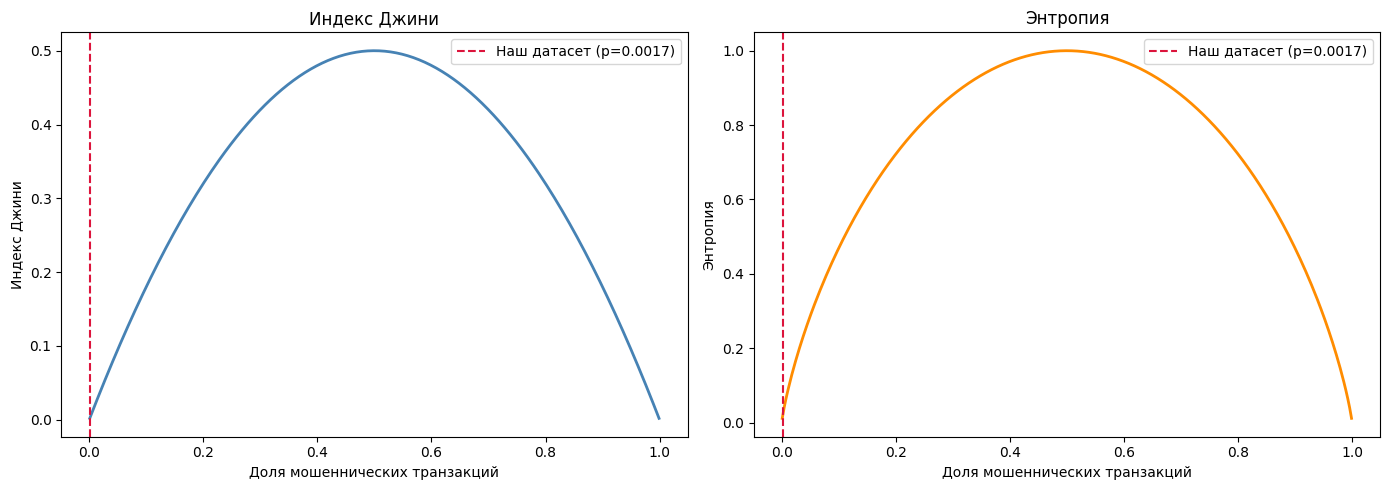

In [26]:
import numpy as np

total = len(df)
p_normal = (df['Class'] == 0).sum() / total
p_fraud  = (df['Class'] == 1).sum() / total

gini = 1 - (p_normal**2 + p_fraud**2)

entropy = -(p_normal * np.log2(p_normal) + p_fraud * np.log2(p_fraud))

print(f"Доля нормальных:     {p_normal:.6f}")
print(f"Доля мошеннических:  {p_fraud:.6f}")
print(f"\nИндекс Джини:  {gini:.6f}")
print(f"Энтропия:      {entropy:.6f}")
# Джини и энтропия внутри каждого класса (идеально чистые узлы)
print("Если узел содержит только нормальные")
p = 1.0
print(f"Джини:    {1 - p**2:.4f}  (0 = идеально чисто)")
print(f"Энтропия: {0:.4f}         (0 = идеально чисто)")

print("\nЕсли узел содержит 50/50")
p = 0.5
gini_50 = 1 - (p**2 + p**2)
entropy_50 = -(p * np.log2(p) + p * np.log2(p))
print(f"Джини:    {gini_50:.4f}  (0.5 = максимальный хаос)")
print(f"Энтропия: {entropy_50:.4f}  (1.0 = максимальный хаос)")

print("\nВесь наш датасет")
print(f"Джини:    {gini:.6f}  (очень чисто — 99.8% один класс)")
print(f"Энтропия: {entropy:.6f}  (очень чисто)")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p_values = np.linspace(0.001, 0.999, 300)

# Джини
gini_values = 1 - (p_values**2 + (1-p_values)**2)
axes[0].plot(p_values, gini_values, color='steelblue', linewidth=2)
axes[0].axvline(p_fraud, color='crimson', linestyle='--',
                label=f'Наш датасет (p={p_fraud:.4f})')
axes[0].set_xlabel('Доля мошеннических транзакций')
axes[0].set_ylabel('Индекс Джини')
axes[0].set_title('Индекс Джини')
axes[0].legend()

# Энтропия
entropy_values = -(p_values * np.log2(p_values) + (1-p_values) * np.log2(1-p_values))
axes[1].plot(p_values, entropy_values, color='darkorange', linewidth=2)
axes[1].axvline(p_fraud, color='crimson', linestyle='--',
                label=f'Наш датасет (p={p_fraud:.4f})')
axes[1].set_xlabel('Доля мошеннических транзакций')
axes[1].set_ylabel('Энтропия')
axes[1].set_title('Энтропия')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Подготовка данных

In [16]:
X = df.drop(columns=['Class'])
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {len(X_train)} записей (fraud: {y_train.sum()})')
print(f'Test:  {len(X_test)} записей (fraud: {y_test.sum()})')

Train: 227845 записей (fraud: 394)
Test:  56962 записей (fraud: 98)


## 6. Стратегии балансировки

In [17]:
def strategy_class_weight(X_train, y_train):
    """Без ресэмплинга — передаём class_weight='balanced' в классификатор."""
    return X_train, y_train, {'class_weight': 'balanced'}


def strategy_undersampling(X_train, y_train):
    """Уменьшаем мажоритарный класс до размера миноритарного."""
    data = pd.concat([X_train, y_train], axis=1)
    majority = data[data['Class'] == 0]
    minority = data[data['Class'] == 1]
    majority_down = resample(majority, replace=False,
                             n_samples=len(minority),
                             random_state=RANDOM_STATE)
    balanced = pd.concat([majority_down, minority])
    return balanced.drop(columns=['Class']), balanced['Class'], {}


def strategy_smote(X_train, y_train):
    """Генерируем синтетические примеры миноритарного класса через SMOTE."""
    sm = SMOTE(random_state=RANDOM_STATE)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    return X_res, y_res, {}


STRATEGIES = {
    'class_weight': strategy_class_weight,
    'undersampling': strategy_undersampling,
    'SMOTE': strategy_smote,
}

print('Стратегии определены')

Стратегии определены


## 7. Обучение моделей


In [18]:
results = {}

for name, strategy_fn in STRATEGIES.items():
    print(f'\n{"="*50}')
    print(f'Стратегия: {name}')
    print(f'{"="*50}')

    X_bal, y_bal, rf_kwargs = strategy_fn(X_train, y_train)
    print(f'  Обучающих примеров: {len(X_bal)} '
          f'(fraud: {y_bal.sum()}, normal: {(y_bal==0).sum()})')

    clf = RandomForestClassifier(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **rf_kwargs
    )
    clf.fit(X_bal, y_bal)

    y_pred = clf.predict(X_test)
    y_prob = clf.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)

    print(f'  ROC-AUC:       {roc_auc:.6f}')
    print(f'  Avg Precision: {ap:.6f}')
    print(f'\n{classification_report(y_test, y_pred, digits=4)}')

    results[name] = dict(
        clf=clf, y_pred=y_pred, y_prob=y_prob,
        roc_auc=roc_auc, ap=ap, cm=cm
    )

print('\nОбучение завершено!')


Стратегия: class_weight
  Обучающих примеров: 227845 (fraud: 394, normal: 227451)
  ROC-AUC:       0.974726
  Avg Precision: 0.829132

              precision    recall  f1-score   support

           0     0.9997    0.9997    0.9997     56864
           1     0.8421    0.8163    0.8290        98

    accuracy                         0.9994     56962
   macro avg     0.9209    0.9080    0.9144     56962
weighted avg     0.9994    0.9994    0.9994     56962


Стратегия: undersampling
  Обучающих примеров: 788 (fraud: 394, normal: 394)
  ROC-AUC:       0.978837
  Avg Precision: 0.697883

              precision    recall  f1-score   support

           0     0.9999    0.9643    0.9818     56864
           1     0.0425    0.9184    0.0812        98

    accuracy                         0.9642     56962
   macro avg     0.5212    0.9413    0.5315     56962
weighted avg     0.9982    0.9642    0.9802     56962


Стратегия: SMOTE
  Обучающих примеров: 454902 (fraud: 227451, normal: 227451)


## 8. Сводная таблица метрик

In [19]:
summary = pd.DataFrame(
    {name: {'ROC-AUC': r['roc_auc'], 'Avg Precision': r['ap']}
     for name, r in results.items()}
).T

print('=== ИТОГОВОЕ СРАВНЕНИЕ ===' )
display(summary.style.highlight_max(color='green').format('{:.6f}'))

best = summary['ROC-AUC'].idxmax()
print(f'\nЛучшая стратегия по ROC-AUC: {best}')

=== ИТОГОВОЕ СРАВНЕНИЕ ===


,ROC-AUC,Avg Precision
class_weight,0.974726,0.829132
undersampling,0.978837,0.697883
SMOTE,0.984630,0.820719



Лучшая стратегия по ROC-AUC: SMOTE


## 9. Матрицы ошибок

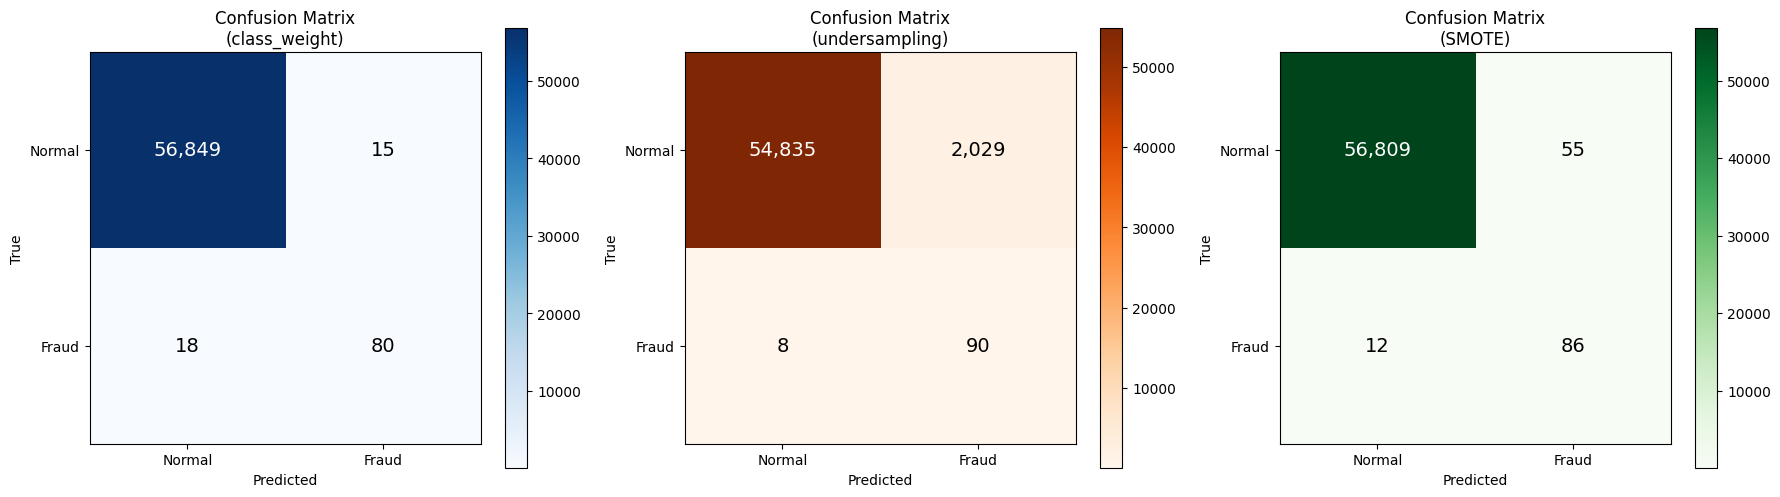

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_list = ['Blues', 'Oranges', 'Greens']

for ax, (name, res), cmap in zip(axes, results.items(), colors_list):
    cm = res['cm']
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    fig.colorbar(im, ax=ax)
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Normal','Fraud'],
           yticklabels=['Normal','Fraud'],
           xlabel='Predicted', ylabel='True',
           title=f'Confusion Matrix\n({name})')
    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    color='white' if cm[i,j] > thresh else 'black', fontsize=14)

plt.tight_layout()
plt.show()

## 10. ROC-кривые

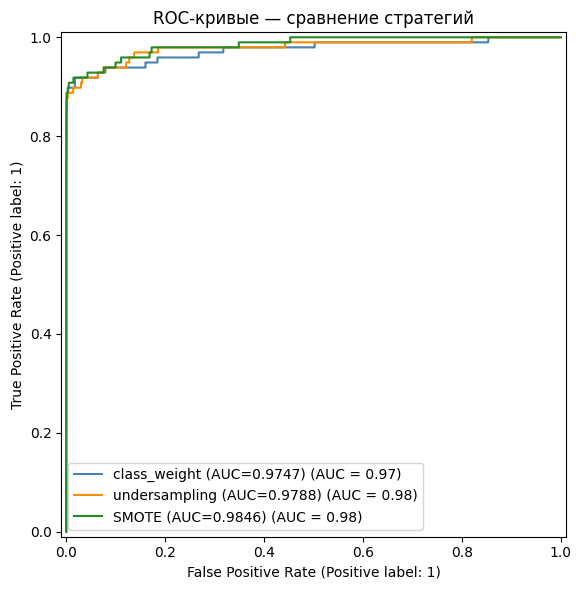

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'forestgreen']

for (name, res), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, res['y_prob'],
        name=f"{name} (AUC={res['roc_auc']:.4f})",
        ax=ax, color=color
    )

ax.set_title('ROC-кривые — сравнение стратегий')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Precision-Recall кривые

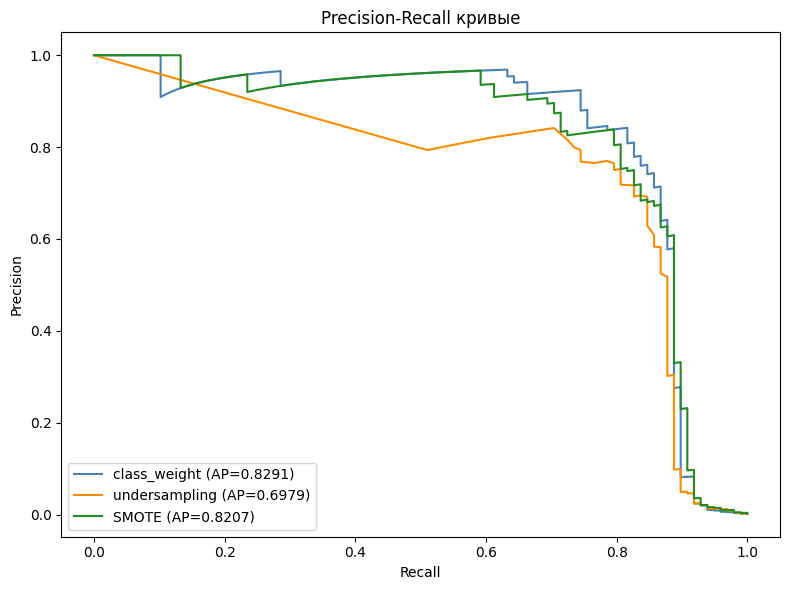

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax.plot(rec, prec, color=color,
            label=f"{name} (AP={res['ap']:.4f})")

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall кривые')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Кривые калибровки

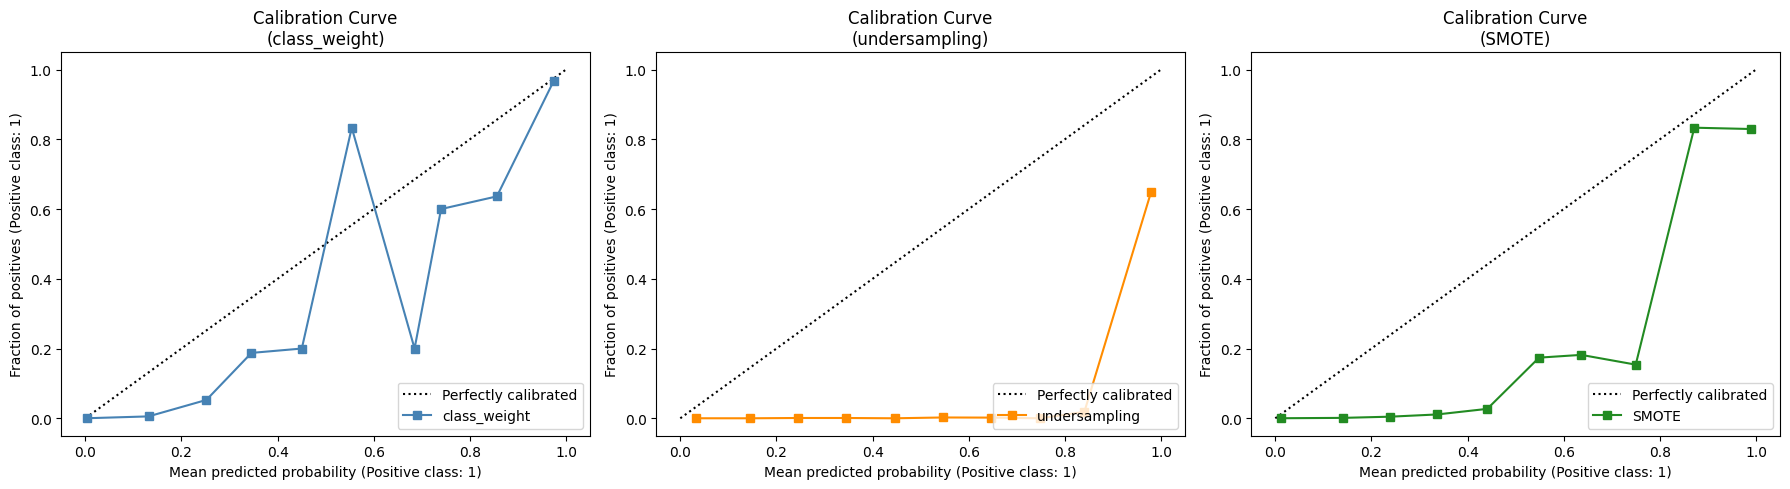

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res), color in zip(axes, results.items(), colors):
    CalibrationDisplay.from_predictions(
        y_test, res['y_prob'],
        n_bins=10, name=name, ax=ax, color=color
    )
    ax.set_title(f'Calibration Curve\n({name})')

plt.tight_layout()
plt.show()

## 13. Важность признаков (лучшая модель)

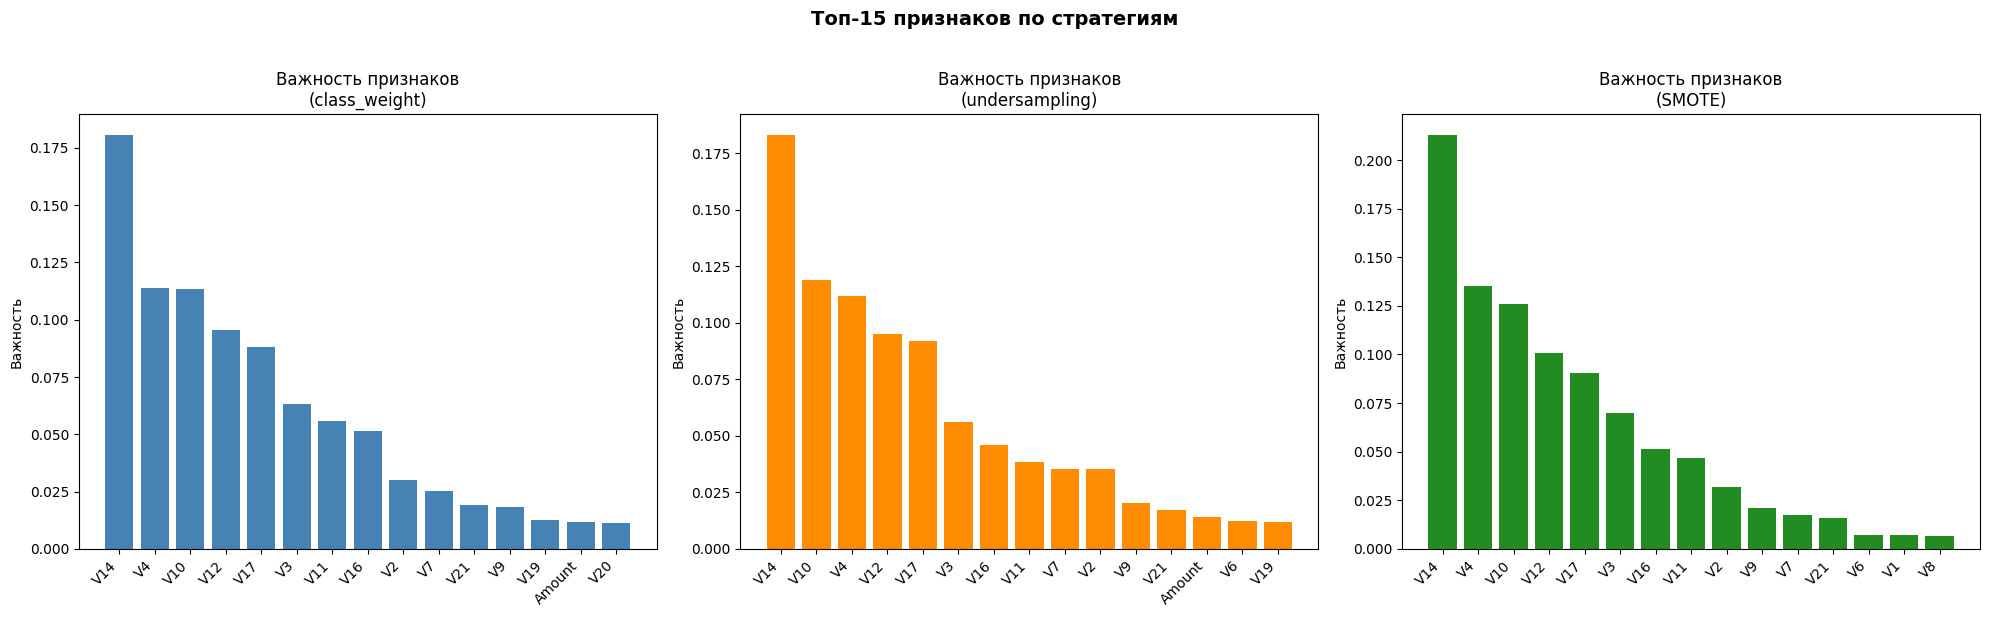

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
colors = ['steelblue', 'darkorange', 'forestgreen']

for ax, (name, res), color in zip(axes, results.items(), colors):
    clf = res['clf']
    importances = clf.feature_importances_
    indices = np.argsort(importances)[::-1][:15]
    feature_names = list(X.columns)

    ax.bar(range(len(indices)), importances[indices], color=color)
    ax.set_xticks(range(len(indices)))
    ax.set_xticklabels([feature_names[i] for i in indices], rotation=45, ha='right')
    ax.set_title(f'Важность признаков\n({name})')
    ax.set_ylabel('Важность')

plt.suptitle('Топ-15 признаков по стратегиям', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()